In [5]:
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [13]:
# import torch 

# class ProbeMLP(torch.nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.L = torch.nn.Linear(100, 1)

#     def forward(self, X):
#         return self.L(X) 

# @torch.no_grad()
# def prepare(model, scale):
#     nps = {n:p for n, p in model.named_parameters()}
#     for name, parameter in nps.items():
#         *module_name, param_name = name.split('.')
#         module = model.get_submodule('.'.join(module_name))

#         module.register_parameter(f'{param_name}_orig', torch.nn.Parameter(parameter * scale))
#         module.register_parameter(f'{param_name}', None)
#         delattr(module, param_name) 


# def add_hook(model, scale):
#     def is_leaf(module):
#         return len(list(module.children())) == 0
#     def _hook(module, input):
        
#         for name, parameter in model.named_parameters():
#             if not name.endswith('_orig'):
#                 continue
#             *module_name, param_name = name.split('.')
#             module = model.get_submodule('.'.join(module_name))
            
#             setattr(module, param_name[:-5], quantize_soft_stairs(parameter, r=0.9999))
        
#         input = tuple(input_i / scale for input_i in input if isinstance(input_i, torch.Tensor) and input_i.dtype == torch.float32)
#         return input 
#     handles = [
#         module.register_forward_pre_hook(_hook, prepend=True) for module in model.modules() if is_leaf(module)
#     ]
#     return handles 

# X = torch.randn(2, 100)
# probe = ProbeMLP()
# scale = 4000
# prepare(probe, scale)
# handles = add_hook(probe, scale) 

 
# probe(X).mean().backward()


In [13]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

TRANSFORMER = "arnir0/Tiny-LLM"
model = AutoModelForSequenceClassification.from_pretrained(TRANSFORMER)
tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER)

Loading weights: 100%|██████████| 11/11 [00:00<00:00, 1795.79it/s]
LlamaForSequenceClassification LOAD REPORT from: arnir0/Tiny-LLM
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
tokenizer.pad_token = tokenizer.eos_token
model.pad_token = tokenizer.eos_token
model(**tokenizer(['What have you done, bastard?', 'So nice to see you!'],  padding=True,
    truncation=True,
    return_tensors="pt"))

ValueError: Cannot handle batch sizes > 1 if no padding token is defined.

In [ ]:
['What have you done, bastard?', 'So nice to see you!'], 

In [11]:
model(torch.randint(0, 100, (21, 100, 512)))

RuntimeError: The size of tensor a (2) must match the size of tensor b (100) at non-singleton dimension 3

In [4]:
del model

In [7]:
import torch
from torch.autograd import Function

class HiddenScale(Function):
    @staticmethod
    def forward(ctx, input, scale):
        # Perform operation without tracking gradients
        ctx.scale = scale
        with torch.no_grad():
            output = input * scale  # Your operation here
        return output
    
    @staticmethod
    def backward(ctx, grad_output):
        # with torch.no_grad():
        #     grad_output = grad_output / ctx.scale
        # Return None or zeros for gradients (hides from autograd)
        # But maintains graph connection
        return grad_output, None # Or return None to stop gradients

# Usage
def hidden_op(x, scale):
    return HiddenScale.apply(x, scale)


class MLP(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim, n_outputs, depth, bias=True, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.bias = bias
        self._nn = torch.nn.Sequential(
            torch.nn.Linear(in_channels, hidden_dim, bias=bias),
            torch.nn.Tanh(), 
            *(torch.nn.Sequential(torch.nn.Linear(hidden_dim, hidden_dim, bias=bias),
                                #    torch.nn.Tanh() if not _ % 2 else 
                                   torch.nn.LeakyReLU(),
                                #    torch.nn.SELU()
                                   ) for _ in range(depth - 2)),
            torch.nn.Linear(hidden_dim, n_outputs, bias = bias), 
            torch.nn.Softmax(-1)
        )

    def forward(self, x):
        return self._nn(x)
    


def generate_non_transformer():
    X = torch.randn(200, 100, device=DEVICE) 
    Y = (torch.rand((200, 10), device=DEVICE)).to(torch.float32)
    mlp = MLP(100, 1024, 10, 5, device=DEVICE)
    return mlp, X, Y
    
from transformers import AutoModelForCausalLM
transformer = AutoModelForSequenceClassification.from_pretrained("arnir0/Tiny-LLM").to(DEVICE)

def generate_transformer():
    X = torch.randint(0, 100, (111, 21, 512), device=DEVICE)
    Y = torch.randn(111, 2, device=DEVICE)
    return transformer, X, Y


@torch.no_grad()
def scale_init(model: torch.nn.Module, scale): 
    for n, p in model.named_parameters():
        if 'bias' in n:
            continue
        p.data *= scale

def is_leaf(module: torch.nn.Module):
    return not len(list(module.children()))

# for linear
def add_input_downscale(model, scale):
    
    hidden_op = lambda x, scale: x * scale
    def _downscale_hook(module, input):
        input = tuple(hidden_op(input_i, 1 / scale) if True or isinstance(input_i, torch.Tensor) else input_i for input_i in input)
        # input = tuple((input_i * 1 / scale) for input_i in input if isinstance(input_i, torch.Tensor))
        return input 

    handles = [
        module.register_forward_pre_hook(_downscale_hook) for module in model.modules() if is_leaf(module) and isinstance(module, torch.nn.Linear)
    ]

    return handles

def add_gradient_upscale(model: torch.nn.Module, scale):
    handles = [parameter.register_hook(lambda x: x * scale) for name, parameter in model.named_parameters() if parameter.requires_grad and 'bias' not in name]
    return handles


# for MHA
def add_activation_downscale(model: torch.nn.Module, scale: float, supported_layers=(torch.nn.MultiheadAttention,)): 
    def activation_downscale(module, args, outputs):
        return outputs / scale 
    
    handles = [
        layer.register_forward_hook(activation_downscale) for layer in model.modules() if type(layer) in supported_layers
    ]
    return handles


# def add_bias_correction(model: torch.nn.Module, scale):
#     return
#     def bias_correction(module: torch.nn.Module, inputs, outputs):
#         with torch.autocast(device_type='cuda', dtype=torch.float64):
#             scale_tensor = torch.scalar_tensor(scale)
#             correction = (1 - 1 / scale_tensor) * module.bias
#         correction = correction.to(module.bias.dtype)
#         if isinstance(outputs, tuple):
#             outputs = (outputs[0] - correction,)
#         else:
#             outputs = (outputs - correction)
#         return outputs
    
#     handles = [
#         layer.register_forward_hook(bias_correction) for layer in model.modules() if isinstance(layer, torch.nn.Linear) and getattr(layer, 'bias', None) is not None
#     ]
#     return handles


model = MLP(100, 1024, 10, 5)
SCALE = 100000
scale_init(model, SCALE)
handles = add_input_downscale(model, SCALE) 
handles_grad_upscale = add_gradient_upscale(model, SCALE)

model_orig = MLP(100, 1024, 10, 5)

from copy import deepcopy

Loading weights: 100%|██████████| 11/11 [00:00<00:00, 1754.20it/s]
LlamaForSequenceClassification LOAD REPORT from: arnir0/Tiny-LLM
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
X = torch.randn(200, 100) 
Y = (torch.rand((200, 10))).to(torch.float32)

In [248]:
loss_fn = lambda model, x: torch.nn.functional.cross_entropy(model(x), Y)

In [ ]:
loss_fn(model, X).backward()
loss_fn(model_orig, X).backward()

# Experiment #1 

how does the scale influence the loss error 


In [8]:
import pandas as pd 
import numpy as np

def one_iter_exp1(scale, loss_fn):
    # model, X, Y = generate_non_transformer()
    model, X, Y = generate_transformer()
    
    model_orig = deepcopy(model)
    # model_orig.load_state_dict(model.state_dict())
    scale_init(model, scale)
    handles = add_input_downscale(model, scale) 
    
    return loss_fn(model(X), Y).detach().item(),  loss_fn(model_orig(X), Y).detach().item()

def run_exp1(loss_funcs, scales, repeats):
    results = pd.DataFrame(columns=['loss', 'scale', 'loss_scaled', 'loss_original'])
    for loss_name, loss_func in loss_funcs.items():
        for scale in scales:
            print('Computing:', loss_name, scale)
            for repeat in range(repeats):
                loss_scaled, loss_orig = one_iter_exp1(loss_fn=loss_func, scale=scale)
                results.loc[results.shape[0]] = (loss_name, scale, loss_scaled, loss_orig) 
    return results 

LOSS_FUNCS = {'crossentropy': torch.nn.functional.cross_entropy, 'mse': torch.nn.functional.mse_loss}
SCALES = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9]

results_exp1 = run_exp1(loss_funcs=LOSS_FUNCS, scales=SCALES, repeats=10)


Computing: crossentropy 1e-09


RuntimeError: The size of tensor a (2) must match the size of tensor b (21) at non-singleton dimension 3

In [113]:
results_exp1['diff'] = np.abs(results_exp1['loss_original'] - results_exp1['loss_scaled'])

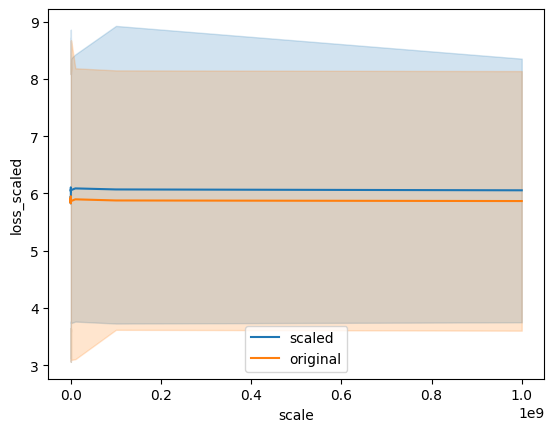

In [114]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.lineplot(results_exp1, x='scale', y='loss_scaled', label='scaled')

sns.lineplot(results_exp1, x='scale', y='loss_original', label='original')
plt.legend()

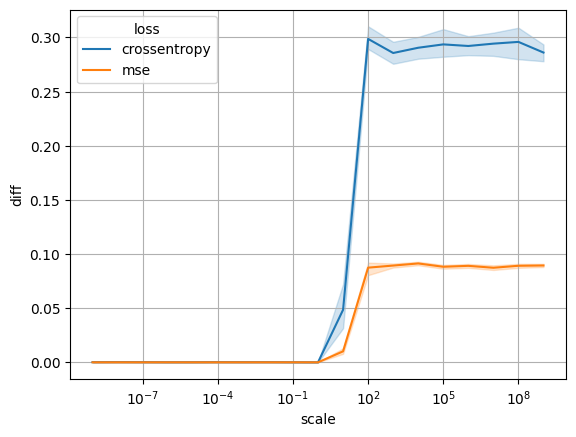

In [212]:
sns.lineplot(results_exp1, x='scale', y='diff',  hue='loss')
plt.xticks(SCALES)
# plt.yscale('log')
plt.xscale('log')
plt.grid()


# Experiment 2: Activation Correctness

In [ ]:
import pandas as pd 
import numpy as np

def add_activation_hook(model):
    activations = {}
    def gather_activation_by_name(name):
        def gather_activations(module, inputs, outputs):
            activations[name] = outputs
        return gather_activations
    handles = [
        layer.register_forward_hook(gather_activation_by_name(name)) for name, layer in model.named_modules() 
    ]
    return activations 

@torch.no_grad()
def activation_analysis(model_scaled, model_original, scaled_activations, original_activations):
    records = []
    for i, (layer_name, layer) in enumerate(model_original.named_modules()):
        
        activation_diff = scaled_activations[layer_name] - original_activations[layer_name]
        records.append(
            dict(zip(('position', 'name', 'layer', 'l2', 'l1', 'absmax', 'absmean', 'relerr'),
            (i, layer_name, layer.__class__.__name__, torch.norm(activation_diff, 2).item(), torch.norm(activation_diff, 1).item(), activation_diff.abs().max().item(), 
             activation_diff.abs().mean().item(), (torch.norm(activation_diff, 2) / torch.norm(original_activations[layer_name], 2)).item())
        )))
    return records


def one_iter_exp2(scale, loss_fn):
    X = torch.randn(200, 100) 
    # Y = (torch.rand((200, 10))).to(torch.float32)
    mlp = MLP(100, 1024, 10, 7)
    mlp_orig = MLP(100, 1024, 10, 7)
    mlp_orig.load_state_dict(mlp.state_dict())
    scale_init(mlp, scale)
    handles = add_input_downscale(mlp, scale) 
    scaled_activations = add_activation_hook(mlp)
    original_activations = add_activation_hook(mlp_orig)
    mlp(X)
    mlp_orig(X)

    records = activation_analysis(mlp, mlp_orig, scaled_activations, original_activations)
    return records

def run_exp2(loss_funcs, scales, repeats):
    results = []
    for loss_name, loss_func in loss_funcs.items():
        for scale in scales:
            defaults = {'loss': loss_name, 'scale': scale}
            print('Computing:', loss_name, scale)
            for repeat in range(repeats):
                records_scaled = one_iter_exp2(loss_fn=loss_func, scale=scale)
                for record in records_scaled:
                    results.append(
                        {**defaults, **record}
                    )

    results = pd.DataFrame(results)
    return results 

LOSS_FUNCS = {'crossentropy': torch.nn.functional.cross_entropy, 'mse': torch.nn.functional.mse_loss}
SCALES = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9]

results_exp2 = run_exp2(loss_funcs=LOSS_FUNCS, scales=SCALES, repeats=10)

Computing: crossentropy 1e-09
Computing: crossentropy 1e-08
Computing: crossentropy 1e-07
Computing: crossentropy 1e-06
Computing: crossentropy 1e-05
Computing: crossentropy 0.0001
Computing: crossentropy 0.001
Computing: crossentropy 0.01
Computing: crossentropy 0.1
Computing: crossentropy 1
Computing: crossentropy 10.0
Computing: crossentropy 100.0
Computing: crossentropy 1000.0
Computing: crossentropy 10000.0
Computing: crossentropy 100000.0
Computing: crossentropy 1000000.0
Computing: crossentropy 10000000.0
Computing: crossentropy 100000000.0
Computing: crossentropy 1000000000.0
Computing: mse 1e-09
Computing: mse 1e-08
Computing: mse 1e-07
Computing: mse 1e-06
Computing: mse 1e-05
Computing: mse 0.0001
Computing: mse 0.001
Computing: mse 0.01
Computing: mse 0.1
Computing: mse 1
Computing: mse 10.0
Computing: mse 100.0
Computing: mse 1000.0
Computing: mse 10000.0
Computing: mse 100000.0
Computing: mse 1000000.0
Computing: mse 10000000.0
Computing: mse 100000000.0
Computing: mse 10

In [265]:
import seaborn as sns 
import matplotlib.pyplot as plt 

In [266]:
results_exp2

,loss,scale,position,name,layer,l2,l1,absmax,absmean,relerr
0,crossentropy,1.000000e-09,0,,MLP,1.173319e-07,0.000001,2.235174e-08,6.705523e-10,2.623260e-08
1,crossentropy,1.000000e-09,1,_nn,Sequential,1.173319e-07,0.000001,2.235174e-08,6.705523e-10,2.623260e-08
2,crossentropy,1.000000e-09,2,_nn.0,Linear,3.202658e-05,0.010227,4.768372e-07,4.993561e-08,1.215570e-07
3,crossentropy,1.000000e-09,3,_nn.1,Tanh,2.367955e-05,0.007577,4.023314e-07,3.699888e-08,1.131354e-07
4,crossentropy,1.000000e-09,4,_nn.2,Sequential,2.297873e-05,0.005788,3.576279e-07,2.826310e-08,2.679715e-07
...,...,...,...,...,...,...,...,...,...,...
7975,mse,1.000000e+09,16,_nn.6,Sequential,1.700945e-06,0.000434,3.725290e-08,2.119925e-09,2.450080e-07
7976,mse,1.000000e+09,17,_nn.6.0,Linear,2.374211e-06,0.000842,3.725290e-08,4.110411e-09,2.478705e-07
7977,mse,1.000000e+09,18,_nn.6.1,LeakyReLU,1.700945e-06,0.000434,3.725290e-08,2.119925e-09,2.450080e-07
7978,mse,1.000000e+09,19,_nn.7,Linear,1.512675e-07,0.000005,1.303852e-08,2.621207e-09,1.623076e-07


In [267]:
results_exp2_ = results_exp2.copy() 
results_exp2_['scale'] = results_exp2_['scale'].astype(str)

/tmp/ipykernel_17761/1807961506.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(results_exp2_,


<Axes: xlabel='l1', ylabel='Density'>

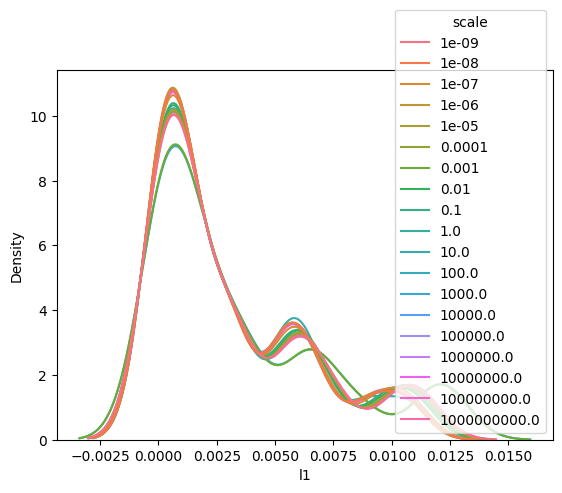

In [269]:
sns.kdeplot(results_exp2_, 
            x='l1', hue='scale')
# plt.yscale('log')
# plt.xscale('log')

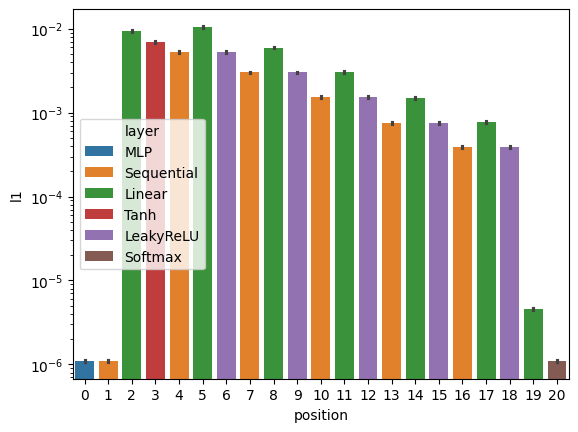

In [270]:
sns.barplot(results_exp2, y='l1', x='position', hue='layer')
plt.yscale('log')

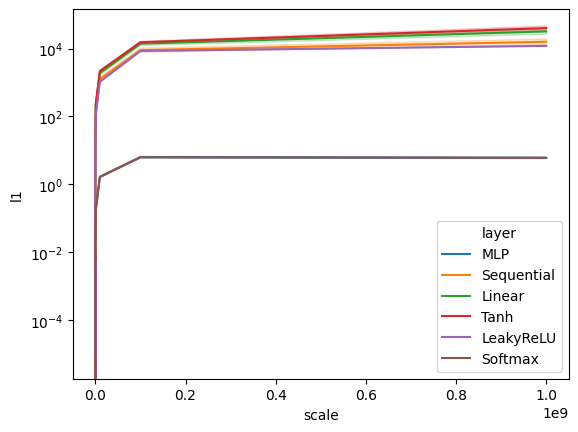

In [197]:
sns.lineplot(results_exp2, y='l1', x='scale', hue='layer')
plt.yscale('log')

# Experiment 3: gradient magnitudes

In [ ]:
@torch.no_grad()
def analyze_magnitudes(model: torch.nn.Module):
    records = []
    for i, (name_p, parameter) in enumerate(model.named_parameters()):
        parameter = parameter.grad
        records.append(
            dict(zip(('position', 'name', 'mean', 'std', 'absmax', 'absmean'),
            (i, name_p, parameter.mean().item(), parameter.std().item(), parameter.abs().max().item(), parameter.abs().mean().item())
        )))
    return records

@torch.no_grad()
def elementwise_analysis(model_scaled, model_orig):
    records = []
    for i, (name_p, param_scaled) in enumerate(model_scaled.named_parameters()):
        param_original = model_orig.get_parameter(name_p)
        grad_diff = param_scaled.grad - param_original.grad
        grad_ratio = param_scaled.grad / param_original.grad
        grad_ratio[torch.isnan(grad_ratio)] = 0
        records.append(
            dict(zip(('position', 'name', 'l2', 'l1', 'absmax', 'absmean', 'relerr', 'grad_ratio'),
            (i, name_p, torch.norm(grad_diff, 2).item(), torch.norm(grad_diff, 1).item(), grad_diff.abs().max().item(), 
             grad_diff.abs().mean().item(), (torch.norm(grad_diff, 2) / torch.norm(param_original.grad, 2)).item(), grad_ratio.mean())
        )))
    return records


def one_iter_exp3(scale, loss_fn):
    X = torch.randn(200, 100) 
    Y = (torch.rand((200, 10))).to(torch.float32)
    mlp = MLP(100, 1024, 10, 5)
    mlp_orig = MLP(100, 1024, 10, 5)
    mlp_orig.load_state_dict(mlp.state_dict())
    scale_init(mlp, scale)
    handles = add_input_downscale(mlp, scale) 
    handles_grad_upscale = add_gradient_upscale(mlp, scale)
    loss_fn(mlp(X), Y).backward()
    loss_fn(mlp_orig(X), Y).backward() 
    records = elementwise_analysis(mlp, mlp_orig)
    return records

def run_exp3(loss_funcs, scales, repeats):
    results = []
    for loss_name, loss_func in loss_funcs.items():
        for scale in scales:
            defaults = {'loss': loss_name, 'scale': scale}
            print('Computing:', loss_name, scale)
            for repeat in range(repeats):
                records_scaled = one_iter_exp3(loss_fn=loss_func, scale=scale)
                for record in records_scaled:
                    results.append(
                        {**defaults, **record}
                    )

    results = pd.DataFrame(results)
    return results 

LOSS_FUNCS = {'crossentropy': torch.nn.functional.cross_entropy, 'mse': torch.nn.functional.mse_loss}
SCALES = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9]

results_exp3 = run_exp3(loss_funcs=LOSS_FUNCS, scales=SCALES, repeats=10)

Computing: crossentropy 1e-09
Computing: crossentropy 1e-08
Computing: crossentropy 1e-07
Computing: crossentropy 1e-06
Computing: crossentropy 1e-05
Computing: crossentropy 0.0001
Computing: crossentropy 0.001
Computing: crossentropy 0.01
Computing: crossentropy 0.1
Computing: crossentropy 1
Computing: crossentropy 10.0
Computing: crossentropy 100.0
Computing: crossentropy 1000.0
Computing: crossentropy 10000.0
Computing: crossentropy 100000.0
Computing: crossentropy 1000000.0
Computing: crossentropy 10000000.0
Computing: crossentropy 100000000.0
Computing: crossentropy 1000000000.0
Computing: mse 1e-09
Computing: mse 1e-08
Computing: mse 1e-07
Computing: mse 1e-06
Computing: mse 1e-05
Computing: mse 0.0001
Computing: mse 0.001
Computing: mse 0.01
Computing: mse 0.1
Computing: mse 1
Computing: mse 10.0
Computing: mse 100.0
Computing: mse 1000.0
Computing: mse 10000.0
Computing: mse 100000.0
Computing: mse 1000000.0
Computing: mse 10000000.0
Computing: mse 100000000.0
Computing: mse 10

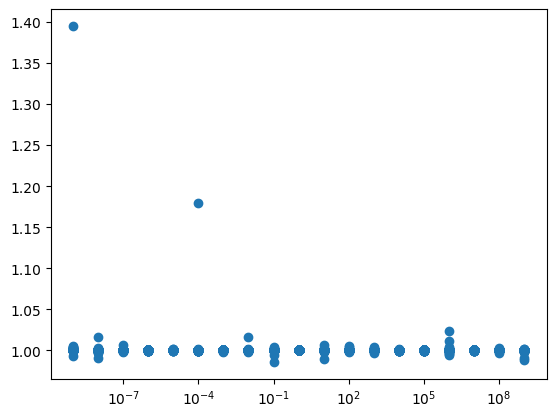

In [279]:
plt.scatter(results_exp3.scale, results_exp3.grad_ratio)
# plt.yscale('log')
plt.xscale('log')

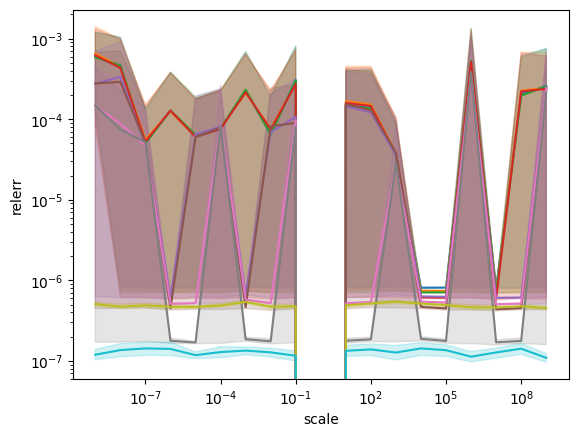

In [280]:
sns.lineplot(results_exp3, x='scale', y='relerr',  hue='name')
plt.xscale('log')
plt.yscale('log')

/tmp/ipykernel_17761/1197715548.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


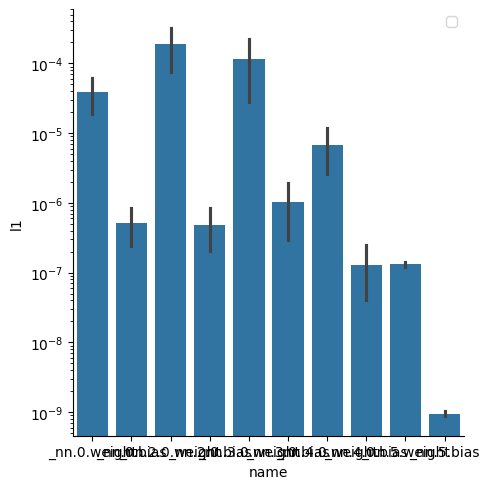

In [283]:
sns.catplot(results_exp3, x='name', y='l1', kind='bar', )
plt.yscale('log')
plt.legend()

/tmp/ipykernel_17761/4076306089.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


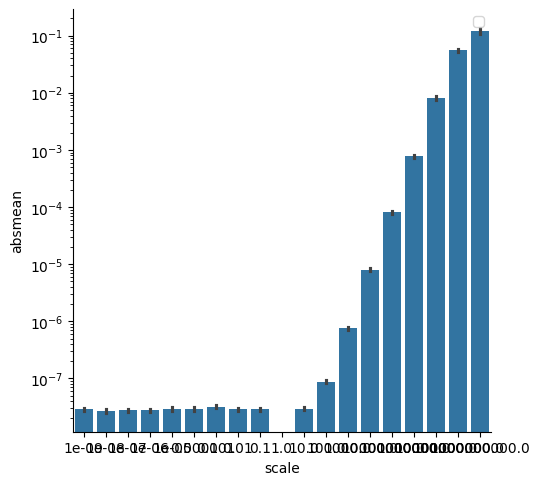

In [160]:
sns.catplot(results_exp2, x='scale', y='absmean', kind='bar' )
plt.yscale('log')
plt.legend()

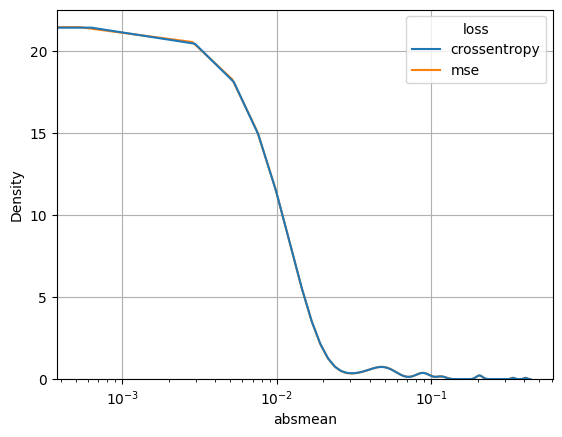

In [161]:
sns.kdeplot(results_exp2, x='absmean', hue='loss')
plt.xscale('log')
plt.grid()